### Building the llama.cpp Inference Framework
After setting up the server environment, clone and build the llama.cpp framework:


In [2]:
#Clone the repository:
!git clone https://github.com/ggerganov/llama.cpp

Cloning into 'llama.cpp'...
remote: Enumerating objects: 133448, done.
remote: Counting objects: 100% (419/419), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 133448 (delta 313), reused 325 (delta 265), pack-reused 133029 (from 1)
Receiving objects: 100% (133448/133448), 438.16 MiB | 55.78 MiB/s, done.
Resolving deltas: 100% (95685/95685), done.


In [3]:
#Configure the build:
!cmake -B llama.cpp/build -S llama.cpp -DCMAKE_CXX_FLAGS="-mcpu=native" -DCMAKE_C_FLAGS="-mcpu=native"

-- The C compiler identification is GNU 13.3.0
-- The CXX compiler identification is GNU 13.3.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- llama.cpp version: 0.5.0-dev
CMAKE_BUILD_TYPE=Release
-- Found Git: /usr/bin/git (found version "2.43.0") 
-- The ASM compiler identification is GNU
-- Found assembler: /usr/bin/cc
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE  
-- Warning: ccache not found - consider installing it for faster compilation or disable this warning with GGML_CCACHE=OFF
-- CMAKE_SYSTEM_PROCESSOR: aarch64
-- GGML_SYSTEM_ARCH: ARM
-- Found

In [4]:
#Compile the framework:
!cmake --build llama.cpp/build --config Release -j$(nproc) -v

Change Dir: '/home/ubuntu/arm/AI-on-Arm/llama.cpp/build'

Run Build Command(s): /usr/bin/cmake -E env VERBOSE=1 /usr/bin/gmake -f Makefile -j4
/usr/bin/cmake -S/home/ubuntu/arm/AI-on-Arm/llama.cpp -B/home/ubuntu/arm/AI-on-Arm/llama.cpp/build --check-build-system CMakeFiles/Makefile.cmake 0
/usr/bin/cmake -E cmake_progress_start /home/ubuntu/arm/AI-on-Arm/llama.cpp/build/CMakeFiles /home/ubuntu/arm/AI-on-Arm/llama.cpp/build//CMakeFiles/progress.marks
/usr/bin/gmake  -f CMakeFiles/Makefile2 all
gmake[1]: Entering directory '/home/ubuntu/arm/AI-on-Arm/llama.cpp/build'
/usr/bin/gmake  -f ggml/src/CMakeFiles/ggml-base.dir/build.make ggml/src/CMakeFiles/ggml-base.dir/depend
/usr/bin/gmake  -f vendor/hash/CMakeFiles/vendor-hash.dir/build.make vendor/hash/CMakeFiles/vendor-hash.dir/depend
/usr/bin/gmake  -f vendor/cpp-httplib/CMakeFiles/cpp-httplib.dir/build.make vendor/cpp-httplib/CMakeFiles/cpp-httplib.dir/depend
/usr/bin/gmake  -f common/CMakeFiles/llama-common-base.dir/build.make common/CM

### Downloading the OpenELM-3B Model Weights
Assuming you've already created the download_openelm.py file from Section 1, proceed with:

In [6]:
#Run the download script:
!python scripts/download_openelm_hf.py

Fetching 11 files:   0%|                                | 0/11 [00:00<?, ?it/s]/home/ubuntu/arm/AI-on-Arm/graviton_env/lib/python3.12/site-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(

README.md: 12.8kB [00:00, 25.4MB/s]

.gitattributes: 1.52kB [00:00, 8.63MB/s]

model-00001-of-00002.safetensors:   0%|            | 0.00/4.94G [00:00<?, ?B/s]

generation_config.json: 100%|█████████████████| 111/111 [00:00<00:00, 1.01MB/s]


configuration_openelm.py: 14.3kB [00:00, 14.6MB/s]A


model-00002-of-00002.safetensors:   0%|            | 0.00/1.13G [00:00<?, ?B/s]


model.safetensors.index.json: 24.2kB [00:00, 86

### Converting and Quantizing the Model

In [2]:
#Once the model has been downloaded, Convert the model to GGUF format:
!mkdir models/gguf_models/

In [3]:
!python llama.cpp/convert_hf_to_gguf.py models/hf_models/OpenELM-3B-Instruct/ --outfile models/gguf_models/OpenELM-3B-Instruct-f16.gguf --outtype f16

INFO:hf-to-gguf:Loading model: OpenELM-3B-Instruct
INFO:hf-to-gguf:Model architecture: OpenELMForCausalLM
INFO:hf-to-gguf:gguf: loading model weight map from 'model.safetensors.index.json'
INFO:hf-to-gguf:gguf: indexing model part 'model-00001-of-00002.safetensors'
INFO:hf-to-gguf:gguf: indexing model part 'model-00002-of-00002.safetensors'
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:blk.0.attn_k_norm.weight,  torch.bfloat16 --> F32, shape = {128}
INFO:hf-to-gguf:blk.0.attn_output.weight,  torch.bfloat16 --> F16, shape = {1536, 3072}
INFO:hf-to-gguf:blk.0.attn_q_norm.weight,  torch.bfloat16 --> F32, shape = {128}
INFO:hf-to-gguf:blk.0.attn_qkv.weight,     torch.bfloat16 --> F16, shape = {3072, 2304}
INFO:hf-to-gguf:blk.0.attn_norm.weight,    torch.bfloat16 --> F32, shape = {3072}
INFO:hf-to-gguf:blk.0.ffn_gate.weight,     torch.bfloat16 --> F16, shape = {3072, 1536}
INFO:hf-to-gguf:blk.0.ffn_up.weight,       to

#### Quantize the model

In [5]:
#For Q8_0 quantization:

!llama.cpp/build/bin/llama-quantize \
    models/gguf_models/OpenELM-3B-Instruct-f16.gguf \
    models/gguf_models/OpenELM-3B-Instruct-q8_0.gguf Q8_0



version: 0.5.0-dev (build 11371, commit 99b95488c)
built with GNU 13.3.0 for Linux aarch64
llama_quantize: quantizing 'models/gguf_models/OpenELM-3B-Instruct-f16.gguf' to 'models/gguf_models/OpenELM-3B-Instruct-q8_0.gguf' as Q8_0
llama_model_loader: loaded meta data with 32 key-value pairs and 326 tensors from models/gguf_models/OpenELM-3B-Instruct-f16.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = openelm
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = OpenELM 3B Instruct
llama_model_loader: - kv   3:                           general.finetune str              = Instruct
llama_model_loader: - kv   4:                           general.basename str              = OpenELM
llam

In [6]:
#For Q4_0 quantization:

!llama.cpp/build/bin/llama-quantize \
    models/gguf_models/OpenELM-3B-Instruct-f16.gguf \
    models/gguf_models/OpenELM-3B-Instruct-q4_0.gguf Q4_0

version: 0.5.0-dev (build 11371, commit 99b95488c)
built with GNU 13.3.0 for Linux aarch64
llama_quantize: quantizing 'models/gguf_models/OpenELM-3B-Instruct-f16.gguf' to 'models/gguf_models/OpenELM-3B-Instruct-q4_0.gguf' as Q4_0
llama_model_loader: loaded meta data with 32 key-value pairs and 326 tensors from models/gguf_models/OpenELM-3B-Instruct-f16.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = openelm
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = OpenELM 3B Instruct
llama_model_loader: - kv   3:                           general.finetune str              = Instruct
llama_model_loader: - kv   4:                           general.basename str              = OpenELM
llam

---

## 3. Benchmarking LLM Inference on Server and Edge


Great! If you've completed all the previous steps, you should now have a compiled `llama.cpp` inference framework on both your local Raspberry Pi and a remote Arm Graviton server. Each setup includes the 3B OpenELM model available in floating-point 16 (`f16`), Int8 (`Q8_0`), and Int4 (`Q4_0`) precisions.


To compare performance between these devices, we’ll focus on throughput-based metrics that can be used to estimate key inference latencies. Two directly measurable metrics provided by `llama.cpp` are:

- **Prompt Processing Rate**, measured in tokens per second (t/s): This metric indicates how quickly the LLM processes the input prompt before generating any output. A higher rate implies better efficiency when handling large prompts.

- **Token Generation Rate**, also in tokens per second (t/s): This measures how quickly new tokens are produced autoregressively during generation. This rate reflects the performance of the decoder and can benefit from optimizations like KV caching.

Although `llama.cpp` does not report latency metrics directly, you can approximate them using these throughput values. For example:
- **Time-to-first-token (TTFT)** ≈ (number_of_prompt_tokens / prompt_processing_rate) + (1 / token_generation_rate)
- **Total inference latency** ≈ (number_of_prompt_tokens / prompt_processing_rate) + (number_of_output_tokens / token_generation_rate)

These derived metrics give insight into user-perceived latency and system responsiveness.

### Benchmarking on AWS Graviton 3

Now, we will compute the same metrics on a remote Graviton server for comparison. To do this, we need to create a benchmark script on the remote server that performs the same experiments.

Ensure you are connected to the Graviton server via SSH in the terminal. Copy the following script and run within the terminal of your AWS instance. 

In [7]:
#!/bin/bash
!mkdir -p openelm_results
 
!llama.cpp/build/bin/llama-bench -m models/gguf_models/OpenELM-3B-Instruct-f16.gguf -p 12 -n 6 --threads 1,2,3,4 | tee openelm_results/f16_grav_results.txt 
!llama.cpp/build/bin/llama-bench -m models/gguf_models/OpenELM-3B-Instruct-q8_0.gguf -p 12 -n 6 --threads 1,2,3,4 | tee openelm_results/q8_grav_results.txt 
!llama.cpp/build/bin/llama-bench -m models/gguf_models/OpenELM-3B-Instruct-q4_0.gguf -p 12 -n 6 --threads 1,2,3,4 | tee openelm_results/q4_grav_results.txt 

| model                          |       size |     params | backend    | threads |            test |                  t/s |
| ------------------------------ | ---------: | ---------: | ---------- | ------: | --------------: | -------------------: |
| openelm 3B F16                 |   5.66 GiB |     3.04 B | CPU        |       1 |            pp12 |          1.77 ± 0.00 |
| openelm 3B F16                 |   5.66 GiB |     3.04 B | CPU        |       1 |             tg6 |          1.66 ± 0.00 |
| openelm 3B F16                 |   5.66 GiB |     3.04 B | CPU        |       2 |            pp12 |          3.55 ± 0.00 |
| openelm 3B F16                 |   5.66 GiB |     3.04 B | CPU        |       2 |             tg6 |          3.25 ± 0.00 |
| openelm 3B F16                 |   5.66 GiB |     3.04 B | CPU        |       3 |            pp12 |          5.31 ± 0.00 |
| openelm 3B F16                 |   5.66 GiB |     3.04 B | CPU        |       3 |             tg6 |          4.83 ± 0.00 |


In [8]:
#Next, we can parse your own results into a pandas dataframe so that we can plot it easily. We can do that by running the below command.
!python scripts/parse_results.py openelm_results/f16_grav_results.txt
!python scripts/parse_results.py openelm_results/q8_grav_results.txt
!python scripts/parse_results.py openelm_results/q4_grav_results.txt


### 4. View Results

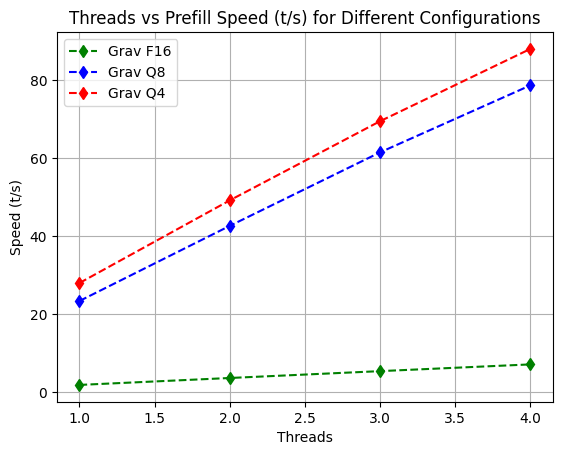

In [11]:
import matplotlib.pyplot as plt
import pandas as pd 

df_grav_f16 = pd.read_csv("openelm_results/f16_grav_results.csv")
df_grav_q8 = pd.read_csv("openelm_results/q8_grav_results.csv")
df_grav_q4 = pd.read_csv("openelm_results/q4_grav_results.csv")

# Filter data for tests starting with 'pp'
filtered_dfs = {
    #"PI Q8": (df_pi_q8, 'blue', 'o', '-'),
    #"PI Q4": (df_pi_q4, 'red', 'o', '-'),
    "Grav F16": (df_grav_f16, 'green', 'd', '--'),
    "Grav Q8": (df_grav_q8, 'blue', 'd', '--'),
    "Grav Q4": (df_grav_q4, 'red', 'd', '--'),
}

# Function to plot speed vs threads
def plot_speed_vs_threads(df, label, color, marker, linestyle):
    filtered_df = df[df['Test'].str.startswith('pp')]
    plt.plot(filtered_df['Threads'], filtered_df['Speed (t/s)'], 
             label=label, marker=marker, color=color, linestyle=linestyle)

# Plot each dataset
for label, (df, color, marker, linestyle) in filtered_dfs.items():
    plot_speed_vs_threads(df, label, color, marker, linestyle)

plt.xlabel('Threads')
plt.ylabel('Speed (t/s)')
plt.title('Threads vs Prefill Speed (t/s) for Different Configurations')
plt.legend()
plt.grid(True)
plt.show()

### **Graph Analysis: Thread Scaling and Bottlenecks**

This graph highlights key differences in how **thread count impacts throughput (tokens per second) during the prompt processing stage** for the Raspberry Pi and Graviton systems.

For **Graviton** (dashed lines), you should observe an almost perfect **linear increase in throughput** as the thread count increases, across all precision levels. This strongly suggests that **prompt processing is compute-bound rather than memory-bound** on Graviton. In other words, the primary bottleneck is the **computational workload** (such as multiply-add-accumulate operations) rather than memory access latency.

In contrast, for the **Raspberry Pi** (solid lines), throughput improvements become **sublinear** as more threads are added. This indicates that the **computation becomes memory-bound**, meaning the processor is increasingly limited by memory access speeds rather than raw compute power. The **Raspberry Pi 5 has only four CPU cores**, and its memory system becomes a bottleneck as more threads compete for bandwidth.

The key reason for this difference lies in the **memory architecture and cache hierarchy** of the two systems. The Raspberry Pi has **much smaller caches**, forcing it to access **slower system memory more frequently**, introducing latency and reducing efficiency. In contrast, the **Graviton server features larger and faster caches**, which can sustain the high memory bandwidth demands of the **3B model**, avoiding major slowdowns as thread count increases.

Additionally, if we look at the **single-threaded performance** (where the *x*-axis=1), we can see that the **Graviton server achieves significantly higher throughput than the Raspberry Pi**, even before scaling up with additional threads. This advantage is not only due to the **higher clock speed** of the Graviton CPU but also the presence of **specialized Arm CPU extensions** that the Raspberry Pi lacks. As covered in **Lab 2**, the Graviton processor includes **DotProd (Dot Product) and I8MM (Integer Matrix Multiplication) instructions**, which accelerate deep learning computations by optimizing tensor operations at the hardware level. These **optimized instructions enable more efficient matrix multiplications**, a key operation in transformer-based models, giving Graviton an edge even in single-threaded execution.

This distinction between **compute-bound vs. memory-bound performance**, along with the impact of **hardware-level optimizations**, highlights the scalability and efficiency differences between edge Arm devices and high-performance Arm servers when running transformer-based models. 🚀

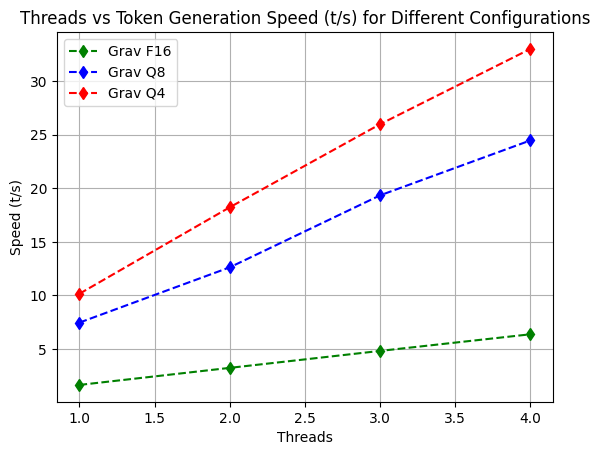

In [13]:
import matplotlib.pyplot as plt

# Define dataset mappings with color, marker, and linestyle
filtered_dfs = {
    #"PI Q8": (df_pi_q8, 'blue', 'o', '-'),
    #"PI Q4": (df_pi_q4, 'red', 'o', '-'),
    "Grav F16": (df_grav_f16, 'green', 'd', '--'),
    "Grav Q8": (df_grav_q8, 'blue', 'd', '--'),
    "Grav Q4": (df_grav_q4, 'red', 'd', '--'),
}

# Function to plot speed vs threads
def plot_speed_vs_threads(df, label, color, marker, linestyle):
    filtered_df = df[df['Test'].str.startswith('tg')]
    plt.plot(filtered_df['Threads'], filtered_df['Speed (t/s)'], 
             label=label, marker=marker, color=color, linestyle=linestyle)

# Loop through datasets and plot
for label, (df, color, marker, linestyle) in filtered_dfs.items():
    plot_speed_vs_threads(df, label, color, marker, linestyle)

plt.xlabel('Threads')
plt.ylabel('Speed (t/s)')
plt.title('Threads vs Token Generation Speed (t/s) for Different Configurations')
plt.legend()
plt.grid(True)
plt.show()


### **Graph Analysis: Token Generation Throughput and Bottlenecks**

In this graph, we observe that **token generation throughput on the Graviton server scales linearly with the number of processing threads**. This suggests that **token generation on Graviton is again compute-bound**, meaning that performance is primarily limited by operation throughput rather than memory access.

For the **Raspberry Pi**, however, you should see that the throughput speed ((t/s) on the graph) remains relatively **flat**, showing little to no improvement as additional threads are added.

The key reason for this difference lies in the computational intensity of these two phases:

- **Prompt processing is highly arithmetic-intensive**, as it requires computing attention across the entire input sequence at once. Each token in the prompt is processed **in parallel**, leading to a large number of floating-point operations per second (**FLOPS**) or tera operations per second (**TOPS**).
- **Token generation, in contrast, is inherently sequential**, with only **one token being generated at a time**. Thanks to the **key-value (KV) cache**, the transformer does not need to recompute attention over all previous tokens from scratch. Instead, it **only retrieves stored key and value activations** from earlier steps and computes attention over them. This significantly **reduces the number of arithmetic operations per token**, making token generation far less compute-intensive than prompt processing.

Because the **feedforward layers in the transformer process each new token independently**, the overall FLOPS/TOPS demand is lower than in the prefill phase. However, token generation introduces **a higher ratio of memory reads to arithmetic operations**:
- The model must **fetch previously stored key-value activations** for attention calculations.
- It must also **load the neural network’s weights** to compute the feedforward layers.
- As a result, **memory bandwidth becomes a key factor** in determining performance.

On **Graviton**, with its **higher memory bandwidth**, token generation remains **compute-bound**, as indicated by the continued increase in throughput with additional threads. The processor can efficiently fetch and process key-value activations while keeping arithmetic units fully utilized.

On the **Raspberry Pi**, however, memory bandwidth is significantly more constrained. Since token generation involves frequent memory accesses to retrieve cached activations, the system quickly becomes **memory-bound**. This explains why **adding more threads does not improve performance** — the bottleneck is not compute power but rather the ability to access memory quickly enough to feed the processor.

---

## 5. Hands-On LLM Interaction

To fully appreciate the difference in performance between the Raspberry Pi and the Graviton server, you should **interact with the models directly**.

#### **Running the Model Locally**
On your **Raspberry Pi**, open a terminal and run the following command:

```bash
python scripts/talk_to_openelm.py
```

At the same time, run the same command in your **SSH session connected to the Graviton server**:

```bash
python scripts/talk_to_openelm.py
```

#### **Things to Observe**
- **Response Speed**: Notice the difference in how quickly tokens are generated on each system.
- **Smoothness of Interaction**: Pay attention to delays when asking follow-up questions.
- **Effect of Precision**: Try modifying the model precision by changing the `-m` argument to a different quantized version (e.g., `q4_0` or `f16`) and see how it impacts performance.

By running the model on both platforms, you will get a **practical, hands-on understanding** of how compute-bound vs. memory-bound constraints impact real-world inference performance. 

Feel free to experiment with different model configurations and report your observations! 🚀

In [19]:
!sh -v ./scripts/chat_f32.sh

#! /bin/bash

./llama.cpp/build/bin/llama-cli -m models/gguf_models/OpenELM-3B-Instruct-f16.gguf -p "Could you write a very simpleprogram in c++ to print hello world in less than 10 lines of code?"

Loading model... 

▄▄ ▄▄
██ ██
██ ██  ▀▀█▄ ███▄███▄  ▀▀█▄    ▄████ ████▄ ████▄
██ ██ ▄█▀██ ██ ██ ██ ▄█▀██    ██    ██ ██ ██ ██
██ ██ ▀█▄██ ██ ██ ██ ▀█▄██ ██ ▀████ ████▀ ████▀
                                    ██    ██
                                    ▀▀    ▀▀

build      : b11371-99b95488c
model      : models/gguf_models/OpenELM-3B-Instruct-f16.gguf
ftype      : F16
modalities : text

available commands:
  /exit or Ctrl+C     stop or exit
  /regen              regenerate the last response
  /clear              clear the chat history
  /read <file>        add a text file
  /glob <pattern>     add text files using globbing pattern



> Could you write a very simpleprogram in c++ to print hello world in less than 10 lines of code?
Let's break this problem into smaller ones:<|in_header pre

In [20]:
!sh -v ./scripts/chat_Q8.sh

#! /bin/bash


llama.cpp/build/bin/llama-cli -m models/gguf_models/OpenELM-3B-Instruct-q8_0.gguf -p "Could you write a very simpleprogram in c++ to print hello world in less than 10 lines of code?"

Loading model... 

▄▄ ▄▄
██ ██
██ ██  ▀▀█▄ ███▄███▄  ▀▀█▄    ▄████ ████▄ ████▄
██ ██ ▄█▀██ ██ ██ ██ ▄█▀██    ██    ██ ██ ██ ██
██ ██ ▀█▄██ ██ ██ ██ ▀█▄██ ██ ▀████ ████▀ ████▀
                                    ██    ██
                                    ▀▀    ▀▀

build      : b11371-99b95488c
model      : models/gguf_models/OpenELM-3B-Instruct-q8_0.gguf
ftype      : Q8_0
modalities : text

available commands:
  /exit or Ctrl+C     stop or exit
  /regen              regenerate the last response
  /clear              clear the chat history
  /read <file>        add a text file
  /glob <pattern>     add text files using globbing pattern



> Could you write a very simpleprogram in c++ to print hello world in less than 10 lines of code?
Let's break this problem down step by step.<|im_step "St

In [21]:
!sh -v ./scripts/chat_Q4.sh

#! /bin/bash

llama.cpp/build/bin/llama-cli -m models/gguf_models/OpenELM-3B-Instruct-q4_0.gguf -p "Could you write a very simpleprogram in c++ to print hello world in less than 10 lines of code?"

Loading model... 

▄▄ ▄▄
██ ██
██ ██  ▀▀█▄ ███▄███▄  ▀▀█▄    ▄████ ████▄ ████▄
██ ██ ▄█▀██ ██ ██ ██ ▄█▀██    ██    ██ ██ ██ ██
██ ██ ▀█▄██ ██ ██ ██ ▀█▄██ ██ ▀████ ████▀ ████▀
                                    ██    ██
                                    ▀▀    ▀▀

build      : b11371-99b95488c
model      : models/gguf_models/OpenELM-3B-Instruct-q4_0.gguf
ftype      : Q4_0
modalities : text

available commands:
  /exit or Ctrl+C     stop or exit
  /regen              regenerate the last response
  /clear              clear the chat history
  /read <file>        add a text file
  /glob <pattern>     add text files using globbing pattern



> Could you write a very simpleprogram in c++ to print hello world in less than 10 lines of code?
Let's break down the problem statement into smaller, mana

As we can see above though the throughput has increased consequently the output quality has also come down